In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
import pandas as pd
from sklearn.metrics import mean_squared_error
from math import cos, asin, sqrt, pi

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing

import ipywidgets as widgets

import sys
sys.path.insert(1, '../Modules/')
from EPE_seasonal_forecast import *

# Outline:

In this last notebook, the actual data-driven seasonal forecast is performed. The optimal combination of predictors emerging from the feature selection step is used to train a data-driven model for predicting the target variable over the training set.

After training, the model is used to generate predictions on the test period, and its performance is quantified using standard validation metrics.

This notebook is structured as follows:

- Step 1: Open the target variable for the location of interest
- Step 2: Extract the optimal combination of predictors
- Step 3: Select the data-driven model to train
- Step 4: Train the model on the training set and forecast NQp over the test set
- Step 5: Visualise the resulting forecast

Cells marked with the “->” symbol require user action.

# Step-1 - Open Target Dataset

-> Define the grid point, accumulation time, percentile threshold and number of evaluations considered in the previous notebook.

In [2]:
### TODO ###
region="Cluj-Napoca"
accumulation_time = 3
quantile = 0.90
num_eval = 3000

Open the target time series NQp generated in the previous notebook for the overlapping seasons.

In [3]:
# read the csv file
target_dataset = pd.read_csv(f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv", index_col='pred_date')

# Step-2 - Extract optimal predictors

Open the file containing the optimal combination predictors obtained in the previous notebook.

In [4]:
# open file containing optimal predictors
indiv_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast.csv'
sol_file_av = pd.read_csv(indiv_file, index_col=None, sep=' ', header=0) 
sols_best = np.fromstring(sol_file_av.Sol[sol_file_av.sort_values(by=['CV'],ascending=True).index[0]].replace('[', '').replace(']', '').replace('\n', ''), dtype=float, sep=' ')

In [5]:
# open predictors file
pred_dataframe = pd.read_csv('../DATA/Predictors_dataset_ERA5_weekly_1940_2024_kmean_1993_2016_0.05_clim_1993_2016_pcs_0.01_centroids_id5_AMJ.csv', index_col=0)

# Step-3 - Select data-driven model

Define the data-driven forecasting models to be evaluated.

Because the training dataset is small, we are constrained to data-driven methods suitable for small-sample regimes to minimize the risk of overfitting.

We will evaluate the following models:

- Linear Regression: A standard multivariate linear fit that minimizes the mean squared error (MSE) on the training set.

- Ridge and Lasso Regression: Regularized linear models that add a penalty term to the loss function (L2 norm for Ridge, L1 norm for Lasso) to prevent overfitting and handle potential multicollinearity.

- Multilayer Perceptron (MLP): A shallow neural network constrained to a single hidden layer of 10 nodes to keep the parameter count low.

- Support Vector Regression (SVR): A machine learning algorithm capable of handling both linear relationships and non-linear patterns through linear and polynomial kernels.

In [6]:
# define the data-driven models to consider
LAS = Lasso(alpha=0.1)

LR = LinearRegression()

RID = Ridge(alpha=10.0)

MLP = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=1e-2,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    max_iter=5000,
    random_state=1
)



SVR_poly = SVR(kernel='poly', C=1, gamma=0.01, epsilon=0.5, degree=3)


SVR_linear = SVR(kernel='linear', C=5, epsilon=0.1)

-> Select the data-driven model to use.

In [7]:
# select dd_driven model

dd_model_widget=widgets.Dropdown(
    options=[ LR, LAS, RID, MLP, SVR_poly, SVR_linear],
    value=LAS,
    description='Data-driven model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='800px')
)

dd_model_widget

Dropdown(description='Data-driven model:', index=1, layout=Layout(width='800px'), options=(LinearRegression(),…

In [8]:
# look at the selected data-driven model
dd_model = dd_model_widget.value
dd_model

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


# Step-4 - Run Forecast

Train the model on the training set and, once trained, use it to generate predictions on the test set.

In [9]:
# define the training period
first_train = "1941-03-17"
last_train = "2011-03-17" 

In [10]:
# call the function for training the model and run the forecast
preds = forecast(target_dataset, first_train, last_train, sols_best, dd_model_widget.value, pred_dataframe)

In [11]:
# set negative values as zero
forecast_train = np.where(preds[2]<0,0,preds[2])
Y_pred = np.where(preds[1]<0,0,preds[1])    

# array of groun truth
gt_train=target_dataset['Target'][first_train:last_train][:-1]
Y_test=target_dataset['Target'][last_train:]

# Step-5 - Visualisation

Inspect the model performance in terms of Root Mean Square Error (RMSE) and Temporal Correlation Coefficient ($\rho$) of the predictions on the test set.

$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$

$\rho = \frac{\sum_{i=1}^{N} (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_{i=1}^{N}(y_i - \bar{y})^2} \sqrt{\sum_{i=1}^{N}(\hat{y}_i - \bar{\hat{y}})^2}}$

$\hat{y}_i$ : predicted values, $y_i$ : ERA5 values

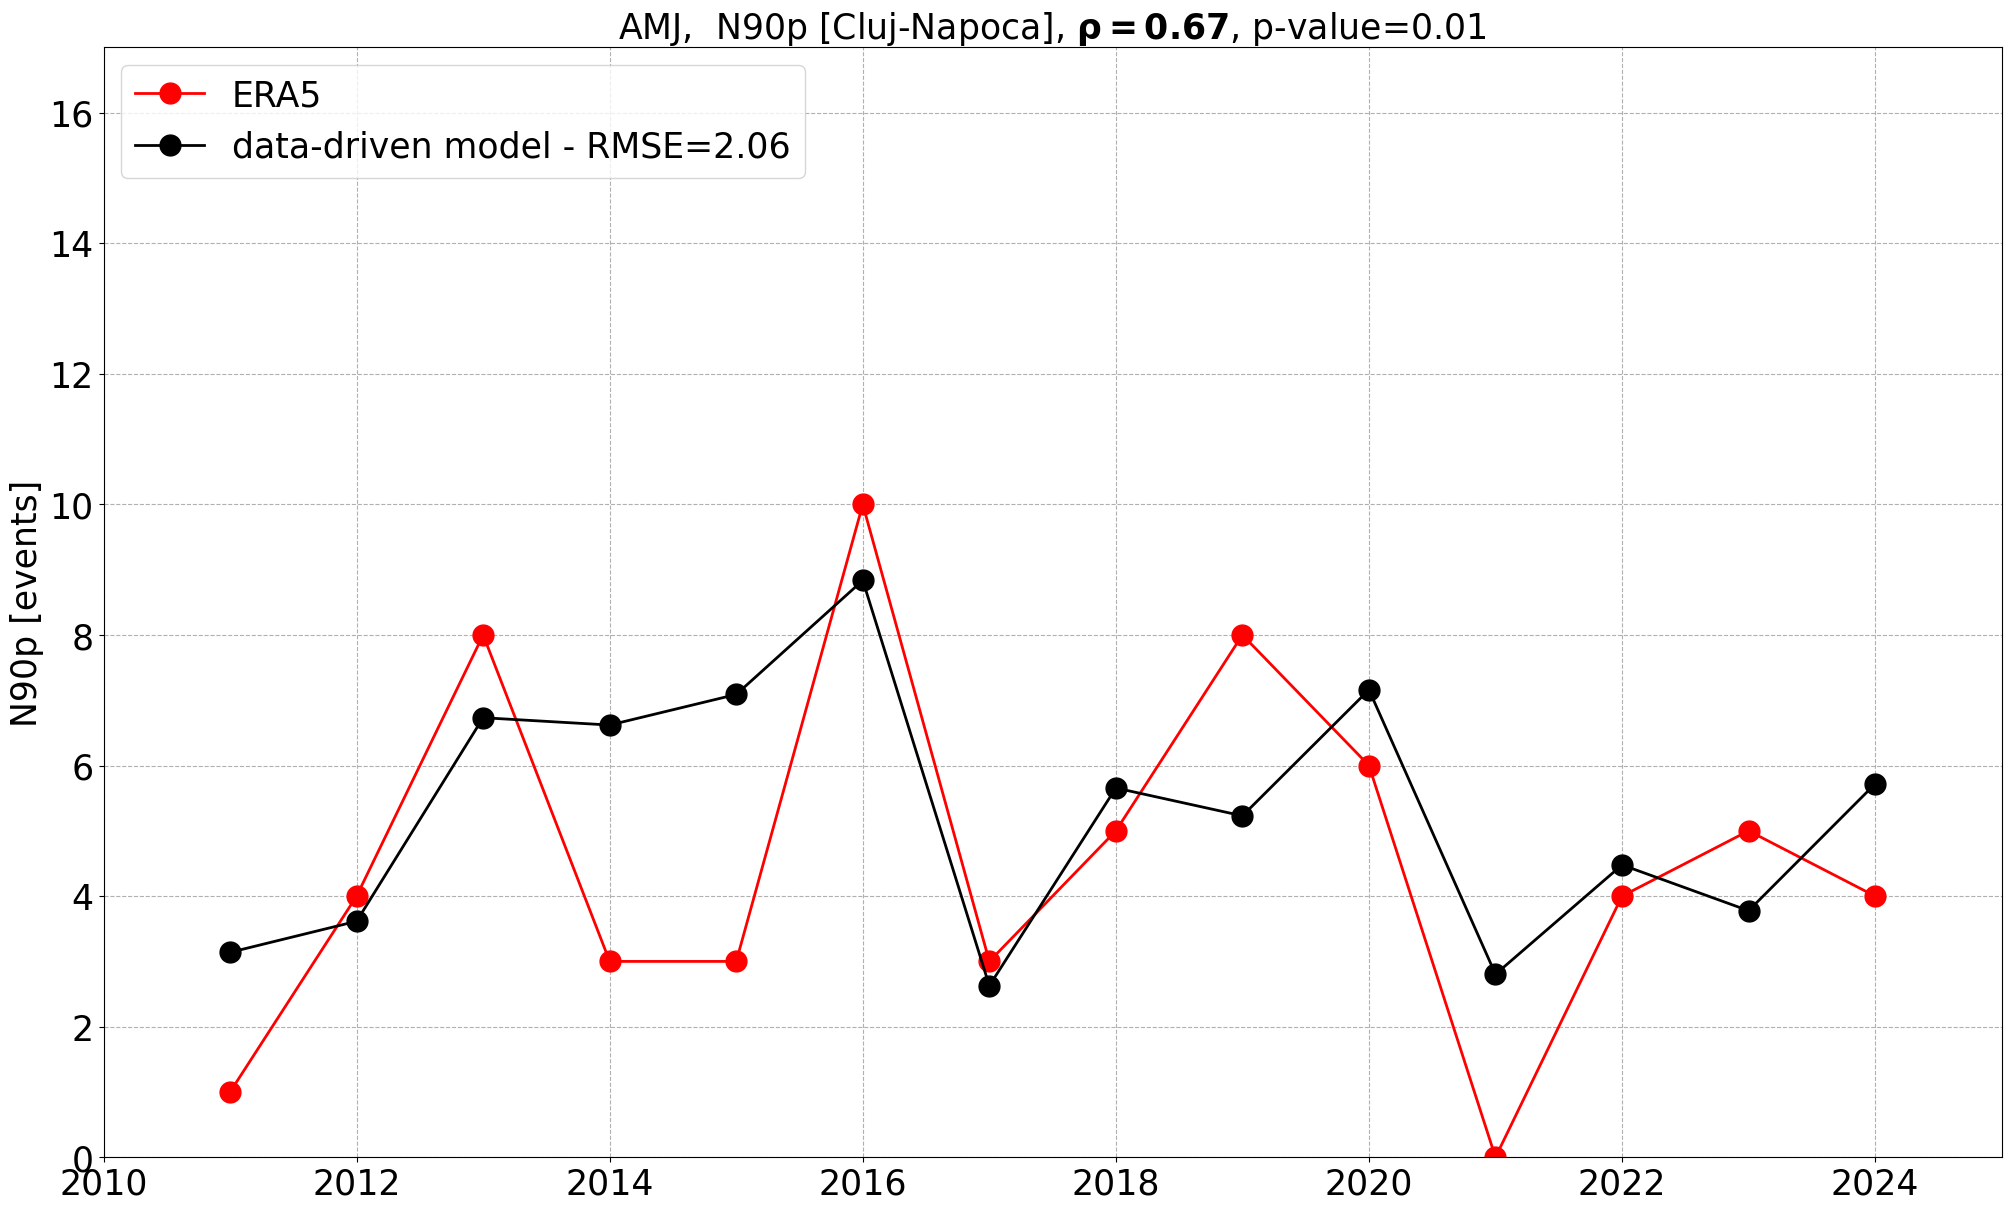

In [12]:
# plot

fig, ax = plt.subplots(figsize=(20, 12), constrained_layout=True)

init = 2
time_step = 5


rmse_forecast = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred[init::time_step]))


ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_test[init::time_step],
    c='red',marker='o', ms = 15, label=f'ERA5',
    linewidth=2)

ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_pred[init::time_step],
    color = 'k', marker='o', ms=15,
    label='{} - RMSE={:.2f}'.format('data-driven model', rmse_forecast),
    linewidth=2
)

corr=sp.pearsonr(Y_test[init::time_step],Y_pred[init::time_step])


ax.legend(loc='upper left', fontsize=25)
ax.set_xlabel('', fontsize=25)
ax.set_ylabel('N{}p [events]'.format(int(quantile*100)), fontsize=25)
ax.set_ylim(0,17)
ax.set_xlim(2010,2025)
ax.tick_params(axis='y', labelsize=25) 
ax.tick_params(axis='x', labelsize=25) 
ax.set_title('AMJ,  N{}p [{}], $\\mathbf{{\\rho = {:.2f}}}$, p-value={:.2f}'.format(int(quantile*100), region, corr.statistic, corr.pvalue), fontsize=25)
ax.grid(ls='--')

# Show the plot
plt.show()

Visualise the predictions from all models and compute their mean (i.e. the average of the individual model predictions).

Ridge
Lasso
SVR (linear)
multi-layer perceptron
SVR (polynomial)


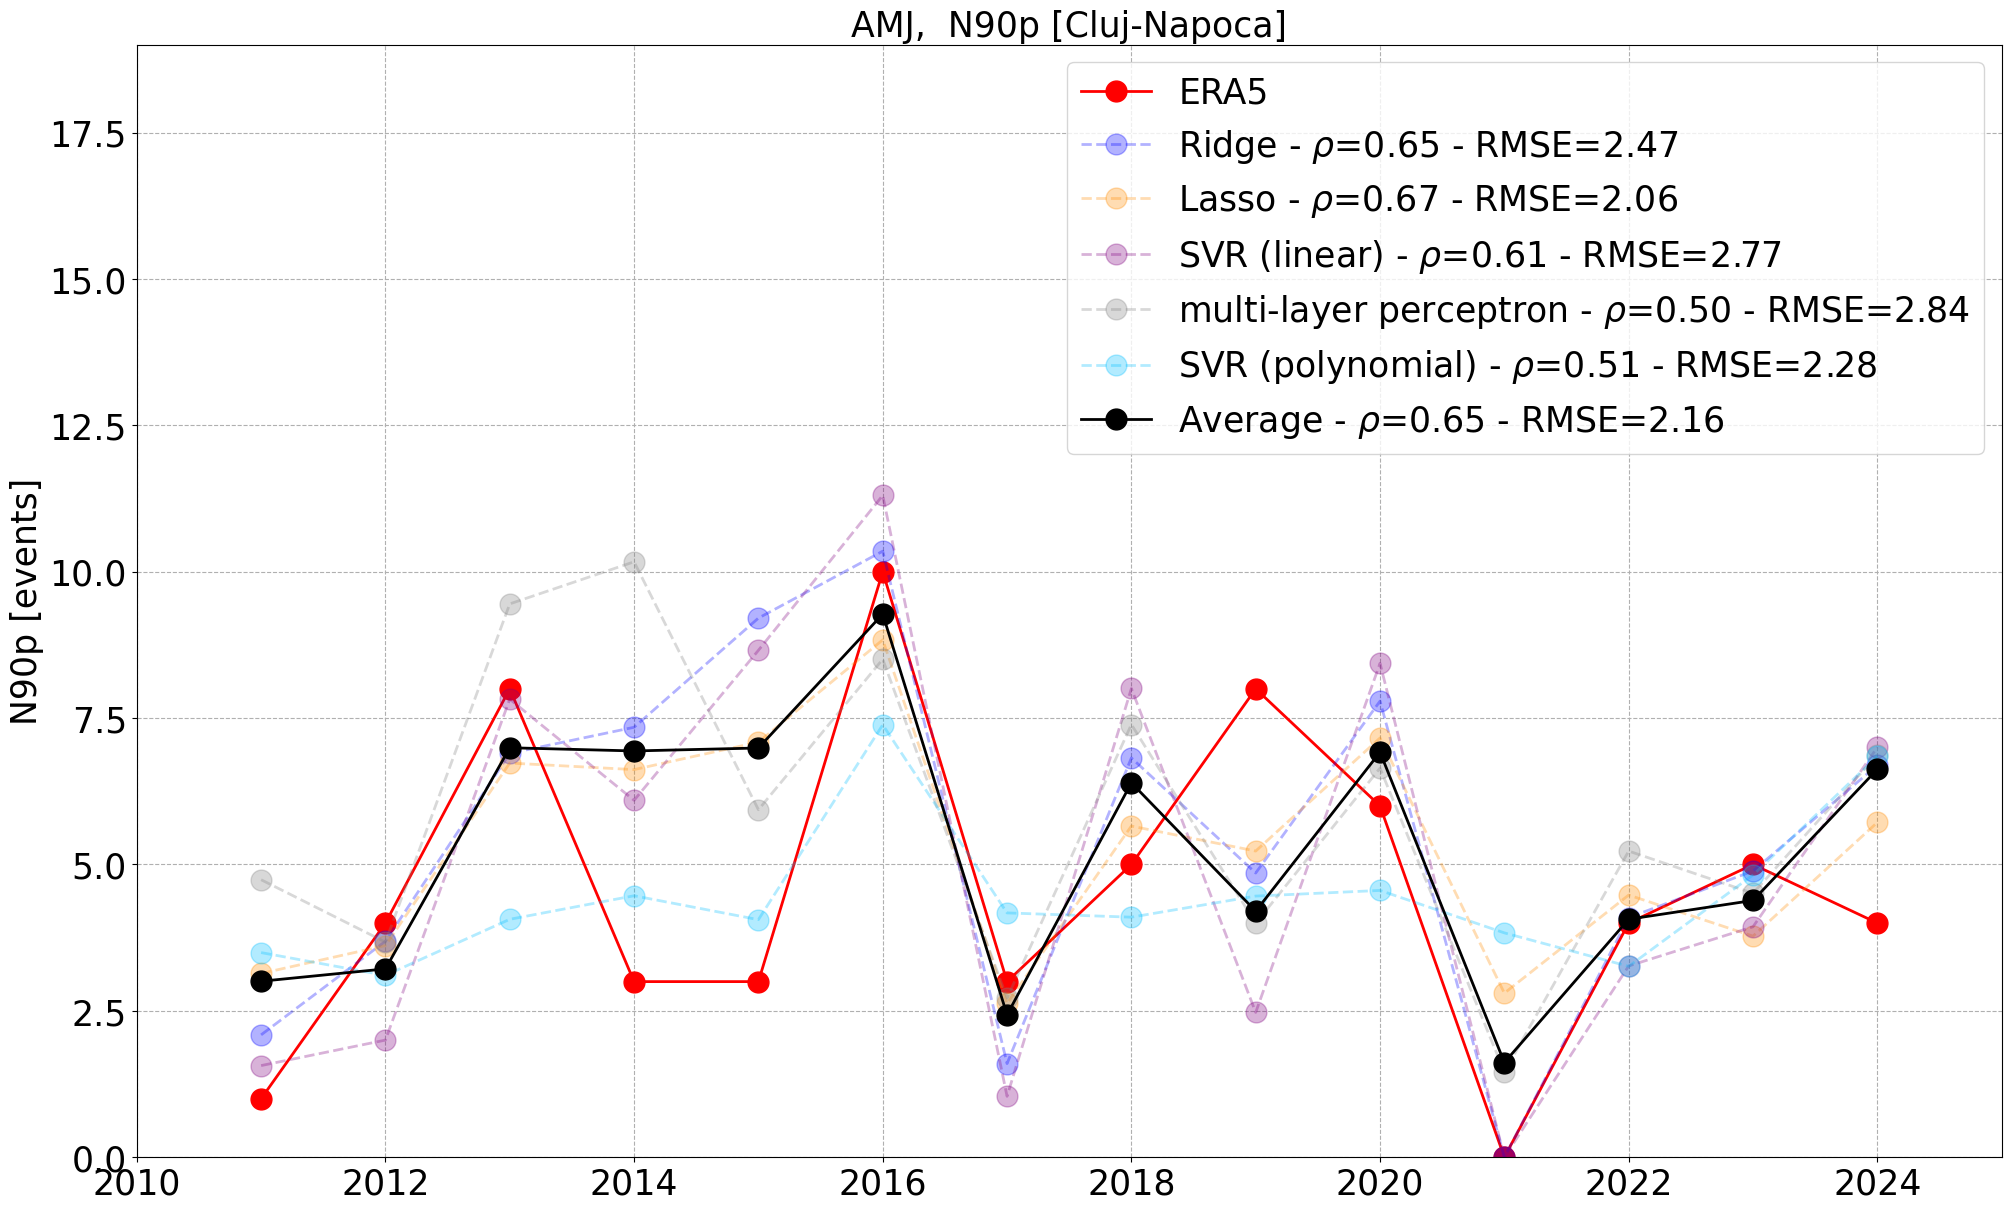

In [13]:
# plot
fig, ax = plt.subplots(figsize=(20, 12), constrained_layout=True)

init = 2
time_step = 5


Y_pred_avg = pd.DataFrame(data = np.zeros((len(Y_test.index))), index=Y_test.index, columns=['Y_pred'])

ax.plot(
    pd.to_datetime(Y_test.index[init::time_step]).year,
    Y_test[init::time_step],
    c='red',marker='o', ms = 15, label=f'ERA5',
    #label=f'Target ({dataset_NQp})',
    linewidth=2)

dd_model_list = [RID, LAS, SVR_linear, MLP, SVR_poly]
dd_model_list_name = ['Ridge', 'Lasso', 'SVR (linear)', 'multi-layer perceptron',  'SVR (polynomial)']
color_list = ['blue', 'darkorange', 'purple', 'gray', 'deepskyblue']


for i in range(len(dd_model_list)):

    dd_model_plot = dd_model_list_name[i]
    dd_model = dd_model_list[i]
    color = color_list[i]
    print(dd_model_plot)

    # prediction
    preds = forecast(target_dataset, first_train, last_train, sols_best, dd_model, pred_dataframe)  
    
    # array of groun truth
    Y_test=target_dataset['Target'][last_train:]



    # set values <0 to 0
    Y_pred = pd.DataFrame(np.where(preds[1]<0,0,preds[1]), columns=['Y_pred'], index=Y_test.index)

    # convert to pd df
    Y_test = pd.DataFrame(Y_test.values, columns=['Y_test'], index=Y_test.index)
    
    Y_pred_avg = Y_pred_avg + Y_pred

    rmse_forecast_dd_model = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred[init::time_step]))
    corr_dd_model=sp.pearsonr(Y_test[init::time_step],Y_pred[init::time_step])

    ax.plot(
    pd.to_datetime(Y_pred.index[init::time_step]).year,
    Y_pred[init::time_step],
    color = color, marker='o', ms=15,
    label='{} - $\\rho$={:.2f} - RMSE={:.2f}'.format(dd_model_plot, corr_dd_model.statistic[0], rmse_forecast_dd_model),
    linewidth=2, alpha = 0.3, ls='--'
    )

rmse_forecast_avg  = np.sqrt(mean_squared_error(Y_test[init::time_step],Y_pred_avg[init::time_step]/len(dd_model_list)))
corr_avg =sp.pearsonr(Y_test[init::time_step],Y_pred_avg[init::time_step]/len(dd_model_list))

ax.plot(
pd.to_datetime(Y_pred_avg.index[init::time_step]).year,
Y_pred_avg[init::time_step]/len(dd_model_list),
color = 'black', marker='o', ms=15,
label='{} - $\\rho$={:.2f} - RMSE={:.2f}'.format('Average', corr_avg.statistic[0], rmse_forecast_avg),
linewidth=2, alpha = 1, ls='-'
)


ax.legend(loc='upper right', fontsize=25)
ax.set_xlabel('', fontsize=25)
ax.set_ylabel('N{}p [events]'.format(int(quantile*100)), fontsize=25)
ax.set_ylim(0,19)
ax.set_xlim(2010,2025)
ax.tick_params(axis='y', labelsize=25) 
ax.tick_params(axis='x', labelsize=25) 
ax.set_title('AMJ,  N{}p [{}]'.format(int(quantile*100), region), fontsize=25)
ax.grid(ls='--')

# Show the plot
plt.show()

-> Which model performs best? Is the average a good option?